In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

In [11]:
df = pd.read_csv('data/raw/hr_attrition.csv')
print(df.shape)
df.head()

(1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [12]:
df.drop(columns=['EmployeeCount', 'Over18', 'StandardHours'], inplace=True)
print(f"Columns remaining: {df.shape[1]}")

Columns remaining: 32


In [13]:
print(df.dtypes)
print("\nNull counts:")
print(df.isnull().sum())

Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EmployeeNumber              int64
EnvironmentSatisfaction     int64
Gender                        str
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                       str
JobSatisfaction             int64
MaritalStatus                 str
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
OverTime                      str
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StockOptionLevel            int64
TotalWorkingYears           int64
TrainingTimesLastYear       int64
WorkLifeBalance             int64
YearsAtCompany              int64
YearsInCurrent

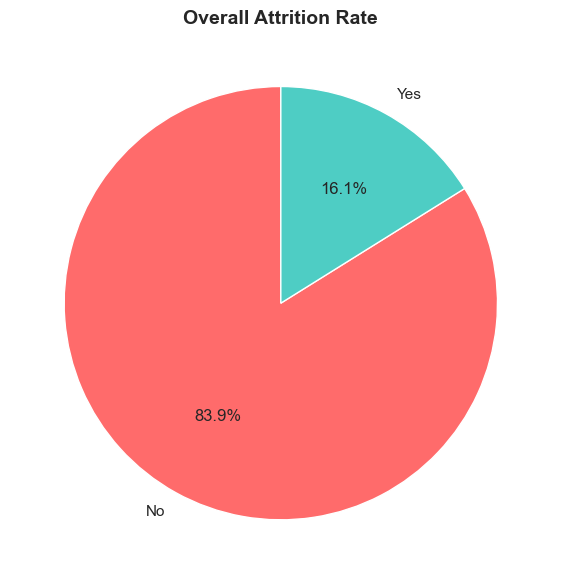

In [16]:
# BQ1 — What is the overall attrition rate in the company?

attrition_counts = df['Attrition'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(attrition_counts, labels=attrition_counts.index, autopct='%1.1f%%',
        colors=['#ff6b6b', '#4ecdc4'], startangle=90)
plt.title('Overall Attrition Rate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/bq1_attrition_rate.png', dpi=150)
plt.show()

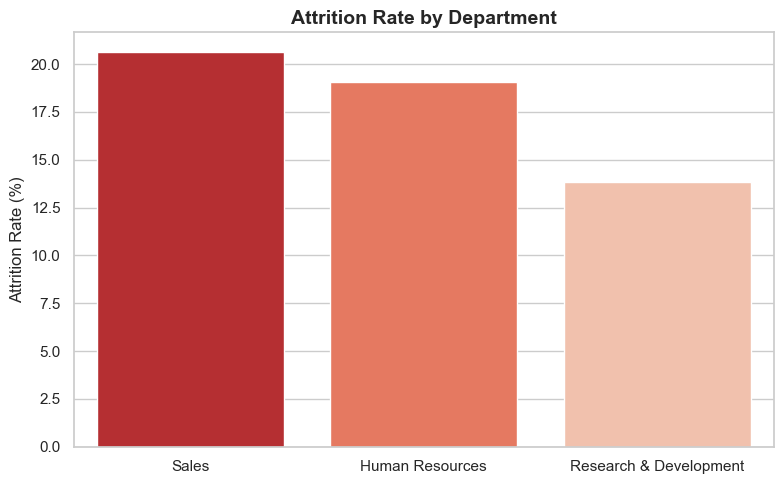

In [21]:
# BQ2 — Which departments have the highest attrition?

dept = df.groupby('Department')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100).reset_index()
dept.columns = ['Department', 'Attrition_Rate']
dept = dept.sort_values('Attrition_Rate', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=dept, x='Department', y='Attrition_Rate',
            hue='Department', palette='Reds_r', legend=False)
plt.title('Attrition Rate by Department', fontsize=14, fontweight='bold')
plt.ylabel('Attrition Rate (%)')
plt.xlabel('')
plt.tight_layout()
plt.savefig('charts/bq2_attrition_by_department.png', dpi=150)
plt.show()

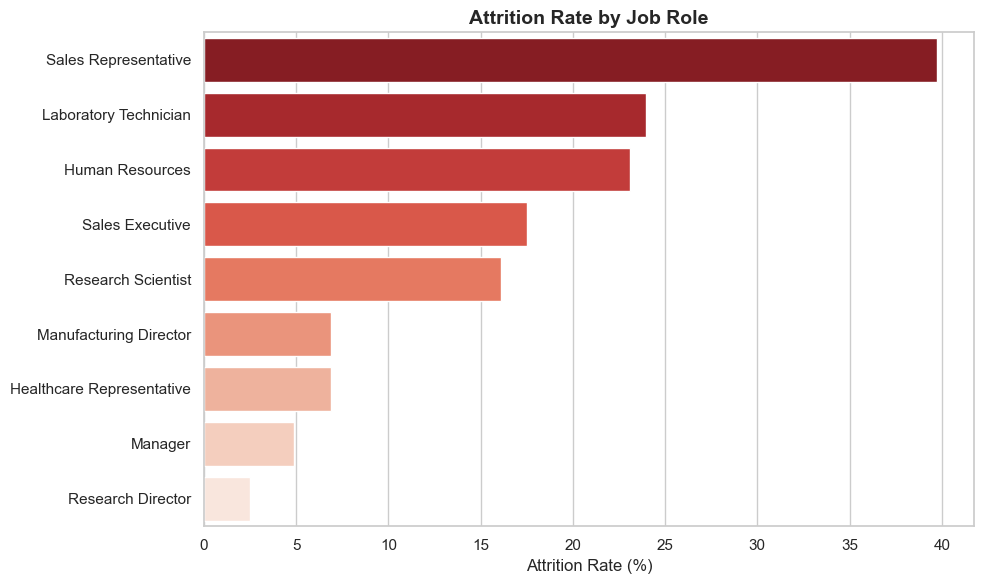

In [22]:
# BQ2 — Which job roles have the highest attrition?

role = df.groupby('JobRole')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100).reset_index()
role.columns = ['JobRole', 'Attrition_Rate']
role = role.sort_values('Attrition_Rate', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=role, x='Attrition_Rate', y='JobRole',
            hue='JobRole', palette='Reds_r', legend=False)
plt.title('Attrition Rate by Job Role', fontsize=14, fontweight='bold')
plt.xlabel('Attrition Rate (%)')
plt.ylabel('')
plt.tight_layout()
plt.savefig('charts/bq2_attrition_by_jobrole.png', dpi=150)
plt.show()

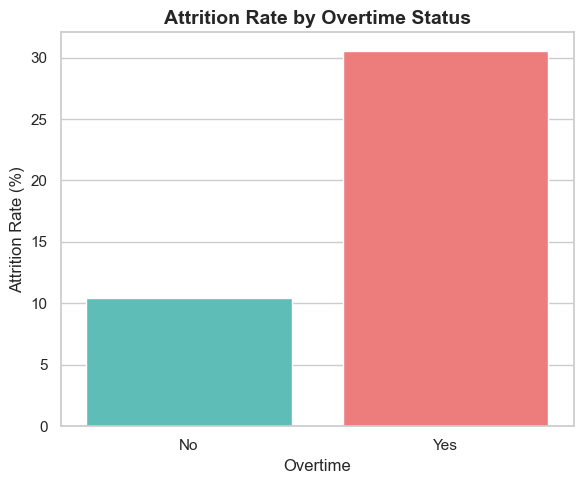

In [23]:
# BQ3 — Does overtime drive attrition?

ot = df.groupby('OverTime')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100).reset_index()
ot.columns = ['OverTime', 'Attrition_Rate']

plt.figure(figsize=(6, 5))
sns.barplot(data=ot, x='OverTime', y='Attrition_Rate',
            hue='OverTime', palette=['#4ecdc4', '#ff6b6b'], legend=False)
plt.title('Attrition Rate by Overtime Status', fontsize=14, fontweight='bold')
plt.ylabel('Attrition Rate (%)')
plt.xlabel('Overtime')
plt.tight_layout()
plt.savefig('charts/bq3_attrition_by_overtime.png', dpi=150)
plt.show()

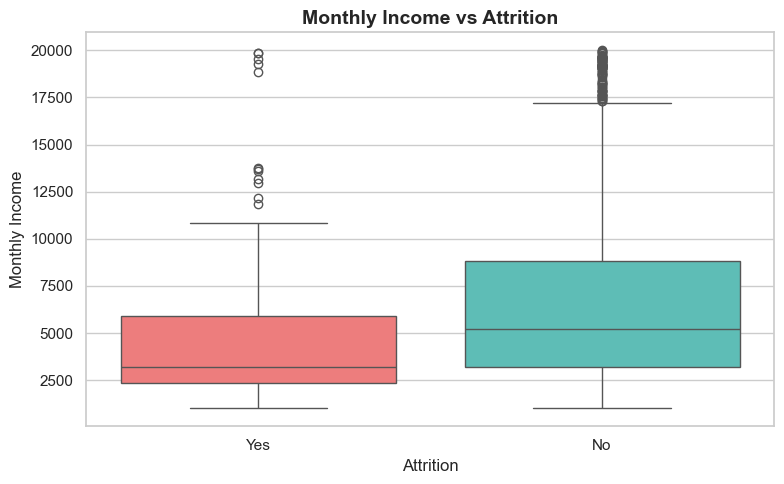

In [25]:
# BQ4 — Do lower paid employees leave more?

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome',
            hue='Attrition', palette={'Yes': '#ff6b6b', 'No': '#4ecdc4'},
            legend=False)
plt.title('Monthly Income vs Attrition', fontsize=14, fontweight='bold')
plt.ylabel('Monthly Income')
plt.xlabel('Attrition')
plt.tight_layout()
plt.savefig('charts/bq4_income_vs_attrition.png', dpi=150)
plt.show()

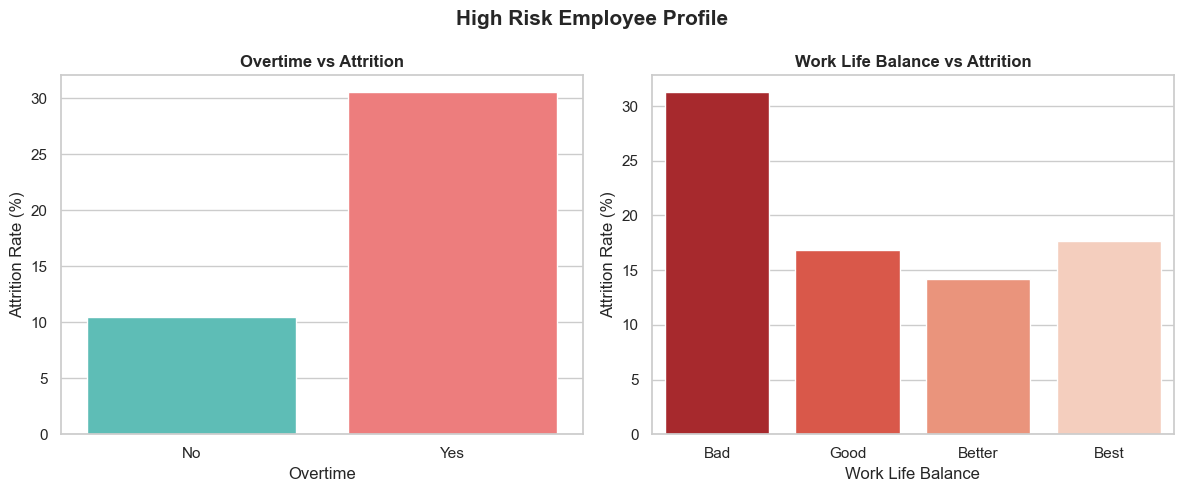

In [26]:
# BQ5 — What does the high risk employee profile look like?
# Combined view: Overtime + Work Life Balance vs Attrition

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left — Overtime by attrition
ot = df.groupby('OverTime')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100).reset_index()
ot.columns = ['OverTime', 'Attrition_Rate']
sns.barplot(data=ot, x='OverTime', y='Attrition_Rate',
            hue='OverTime', palette=['#4ecdc4', '#ff6b6b'],
            legend=False, ax=axes[0])
axes[0].set_title('Overtime vs Attrition', fontweight='bold')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].set_xlabel('Overtime')

# Right — Work Life Balance by attrition
wlb = df.groupby('WorkLifeBalance')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100).reset_index()
wlb.columns = ['WorkLifeBalance', 'Attrition_Rate']
wlb['WLB_Label'] = wlb['WorkLifeBalance'].map(
    {1: 'Bad', 2: 'Good', 3: 'Better', 4: 'Best'})
sns.barplot(data=wlb, x='WLB_Label', y='Attrition_Rate',
            hue='WLB_Label', palette='Reds_r',
            legend=False, ax=axes[1])
axes[1].set_title('Work Life Balance vs Attrition', fontweight='bold')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].set_xlabel('Work Life Balance')

fig.suptitle('High Risk Employee Profile', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/bq5_high_risk_profile.png', dpi=150)
plt.show()

In [28]:
# Export cleaned dataset for Looker Studio
df.to_csv('data/cleaned/hr_attrition_cleaned.csv', index=False)
print("Cleaned file exported successfully.")

Cleaned file exported successfully.
